# **Customer Behaviour Analysis With Customer Lifetime Value**

## **Introduction**



### **GOAL**

Compute **Customer Lifetime Value (CLV)** refers to the total expected revenue a business can earn from a customer throughout their relationship. The longer a customer remains active and the more frequently they purchase, the higher their CLV.

A common way to estimate customer value over time is the **RFM model**, which considers:

- __Recency (R)__ : How recently the customer made a purchase.

- __Frequency (F)__ : How often the customer makes purchases.

- __Monetary (M)__ : How much the customer spends.

- __T (Tenure)__ : The duration between their first purchase and the end of the study period.


#### **Customer Personality Dataset Description:**

The Customer Personality Analysis dataset is a Kaggle dataset designed for customer segmentation, containing demographic details, spending habits, and product preferences of retail customers. It's widely used for clustering, profiling, predict campaign success, and marketing strategy optimization.


### **Feature Distribution:**

**1. Customer Information**
- ID – Unique identifier for each customer
- Year_Birth – Customer's birth year
- Education – Level of education
- Marital_Status – Marital status

**2. Financial Details**
- Income – Annual household income
- Kidhome – Number of children at home
- Teenhome – Number of teenagers at home

**3. Purchase Behavior**
- Recency – Days since last purchase
- MntWines – Amount spent on wine
- MntFruits – Amount spent on fruits
- MntMeatProducts – Amount spent on meat products
- MntFishProducts – Amount spent on fish products
- MntSweetProducts – Amount spent on sweets
- MntGoldProds – Amount spent on gold products

**4. Purchase Channels**
- NumDealsPurchases – Number of purchases made with discount
- NumWebPurchases – Purchases made online
- NumCatalogPurchases – Purchases via catalog
- NumStorePurchases – Purchases in-store
- NumWebVisitsMonth – Monthly website visits

**5. Campaign Response**
- AcceptedCmp1–AcceptedCmp5 – Acceptance of previous campaigns
- Response – Response to the last campaign (Target variable)

**6. Customer Engagement**
- Complain – Whether the customer complained
- Dt_Customer – Date of customer enrollment


**This dataset represents the customers profile and behaviour across multiple years, where each row corresponds to one customer. It includes demographic details, family composition, income, purchasing behaviour and product spending.**

### **1. Data Ingestion & Understanding**

In [132]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown


In [133]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [134]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'raw')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   marketing_campaign.csv


In [135]:
display_md("**Loading Raw Dataset...**")
try:
    customer_org = pd.read_csv(files[0], sep='\t')
    
    # standardize the column names
    customer_org.columns = customer_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_data = customer_org.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
    display_md(f"**Dataset Shape : {customer_data.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_data.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")

**Loading Raw Dataset...**

**Dataset Shape : (2240, 29)**

**Number of duplicate rows in dataset : 0**

In [136]:
customer_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [137]:
display_md(f"**Customer Information :**")
customer_data.info()

**Customer Information :**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

- `Education` & 'Marital_Status' are two categorical features.
- `Dt_Customer` only datetime feature.
- Other features are numbers.

In [138]:
## Column Formatting & Consistency
dtype_df = pd.DataFrame(
    index=customer_data.columns, columns=['dtype', 'nunique', 'unique']
)
dtype_df['dtype'] = customer_data.dtypes
dtype_df['nunique'] = customer_data.nunique()
dtype_df['unique'] = [customer_data[col].unique() for col in dtype_df.index]

display(dtype_df)

,dtype,nunique,unique
ID,int64,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177..."
Year_Birth,int64,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 198..."
Education,object,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
Marital_Status,object,8,"[Single, Together, Married, Divorced, Widow, A..."
Income,float64,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, ..."
Kidhome,int64,3,"[0, 1, 2]"
Teenhome,int64,3,"[0, 1, 2]"
Dt_Customer,datetime64[ns],663,"[2012-09-04 00:00:00, 2014-03-08 00:00:00, 201..."
Recency,int64,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 8..."
MntWines,int64,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6..."


## **2. EDA**

**2.1. Missing Values Analysis & Imputation**

In [139]:
miss_df = customer_data.stb.missing().query('percent > 0')
miss_df

,missing,total,percent
Income,24,2240,1.071429


- `Income` is only feature with missing values.

In [140]:
# drop NA values
customer_df = customer_data.dropna()
customer_df.shape

(2216, 29)

__2.2. Categorical Features__

In [141]:
categorical_cols = customer_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['Education', 'Marital_Status']

In [142]:
# Check education if need some correction
print(f"Education Original Distribution : {customer_data['Education'].value_counts(normalize=True)}")

# Segmenting eduction level in 4 groups
customer_df.loc[:,'Education'] = customer_df['Education'].replace({
    'PhD':'PhD',
    'Master':'PostGraduation',
    '2n Cycle':'PostGraduation',
    'Graduation':'Graduation',
    'Basic':'UnderGraduation'
})
print("="*50)
print(f"Education Altered Distribution : {customer_df['Education'].value_counts(normalize=True)}")

Education Original Distribution : Education
Graduation    0.503125
PhD           0.216964
Master        0.165179
2n Cycle      0.090625
Basic         0.024107
Name: proportion, dtype: float64
Education Altered Distribution : Education
Graduation         0.503610
PostGraduation     0.254964
PhD                0.217058
UnderGraduation    0.024368
Name: proportion, dtype: float64


- Half of the customers are university graduates. There are more customers with a Master's degree than customers with a PhD, only few customers have high school degree.

In [143]:
# Check marital status if need some correction
print(f"Marital Status Original Distribution : {customer_data['Marital_Status'].value_counts(normalize=True)}")

# Segmenting marital status level in 2 groups
customer_df.loc[:,'Marital_Status'] = customer_df['Marital_Status'].replace({
    'Married':'Partner',
    'Together':'Partner',
    'Divorced':'Single',
    'Widow' : 'Single',
    'Alone' : 'Single',
    'Absurd': 'Single',
    'YOLO' : 'Single'
})
print("="*50)
print(f"Marital Status Altered Distribution : {customer_df['Marital_Status'].value_counts(normalize=True)}")


Marital Status Original Distribution : Marital_Status
Married     0.385714
Together    0.258929
Single      0.214286
Divorced    0.103571
Widow       0.034375
Alone       0.001339
Absurd      0.000893
YOLO        0.000893
Name: proportion, dtype: float64
Marital Status Altered Distribution : Marital_Status
Partner    0.645307
Single     0.354693
Name: proportion, dtype: float64


- 2/3 of customers live with a partner while about 1/3 are still single.

**2.3. Feature Engineering**

In [144]:
customer_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

**2.3.1. Customer's Age**

To calculate each customer's age, we use their year of birth. Since customer registrations occurred between 2012 and 2014, we assume the dataset was collected in January 2015, and ages are computed relative to that date.

In [145]:
customer_df = customer_df.assign(
    Age=2015 - customer_df['Year_Birth']
)

**2.3.2.1. Is_parent**

To determine whether a customer is a parent, we add the values of Kidhome and Teenhome. If the sum is greater than zero, the customer is classified as a parent (1); otherwise, they are not (0).

In [146]:
customer_df['Is_parent'] = (
    customer_df['Kidhome'] + customer_df['Teenhome'] > 0
).astype(int)

In [147]:
customer_df['Is_parent'].value_counts(normalize=True)

Is_parent
1    0.71435
0    0.28565
Name: proportion, dtype: float64

- A majority of customers (71%) are parents, whereas 29% fall into the non-parent category.

**2.3.2.2. Total Children at Home**

Merging Kidhome and Teenhome into a single feature representing the total number of children living at home.

In [148]:
customer_df = customer_df.assign(
    Children=customer_df['Kidhome'] + customer_df['Teenhome']
)

**2.3.3. Date Components Extraction**

In [149]:
import datetime as dt
customer_df = customer_df.assign(
    Day=customer_df['Dt_Customer'].dt.day,
    Month=customer_df['Dt_Customer'].dt.month,
    Quarter=customer_df['Dt_Customer'].dt.quarter,
    Year=customer_df['Dt_Customer'].dt.year
)
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014


**2.3.4. Monetry**

Aggregate the expenses across all product categories to compute each customer's total expenditure.

In [150]:
customer_df = customer_df.assign(
    Monetary=(
        customer_df['MntFishProducts']
        + customer_df['MntGoldProds']
        + customer_df['MntFruits']
        + customer_df['MntMeatProducts']
        + customer_df['MntSweetProducts']
        + customer_df['MntWines']
    )
)

**2.3.5. Frequency**

Use features like `NumWebPurchases`, `NumCatalogPurchases`, and `NumStorePurchases` to compute how often a customer shops across different channels.

In [151]:
customer_df = customer_df.assign(
    Frequency=customer_df[
        ['NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases']
    ].sum(axis=1)
)

**2.3.6. Tenure**

Computing how many months each customer has been connected to the company based on their registration date.

In [152]:
reference_date = pd.to_datetime('2015-01-01')

# Calculate tenure in months
customer_df = customer_df.assign(
    Tenure=(
        (reference_date - customer_df['Dt_Customer']).dt.days / 30
    ).astype(int)
)

In [153]:
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,776,20,16
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,53,6,10
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,422,14,11


**2.4. Identify Outliers**


Statistics of Age:
    Skewness : 0.3537
    Kurtosis : 0.7347
Statistics of Income:
    Skewness : 6.7635
    Kurtosis : 159.6367


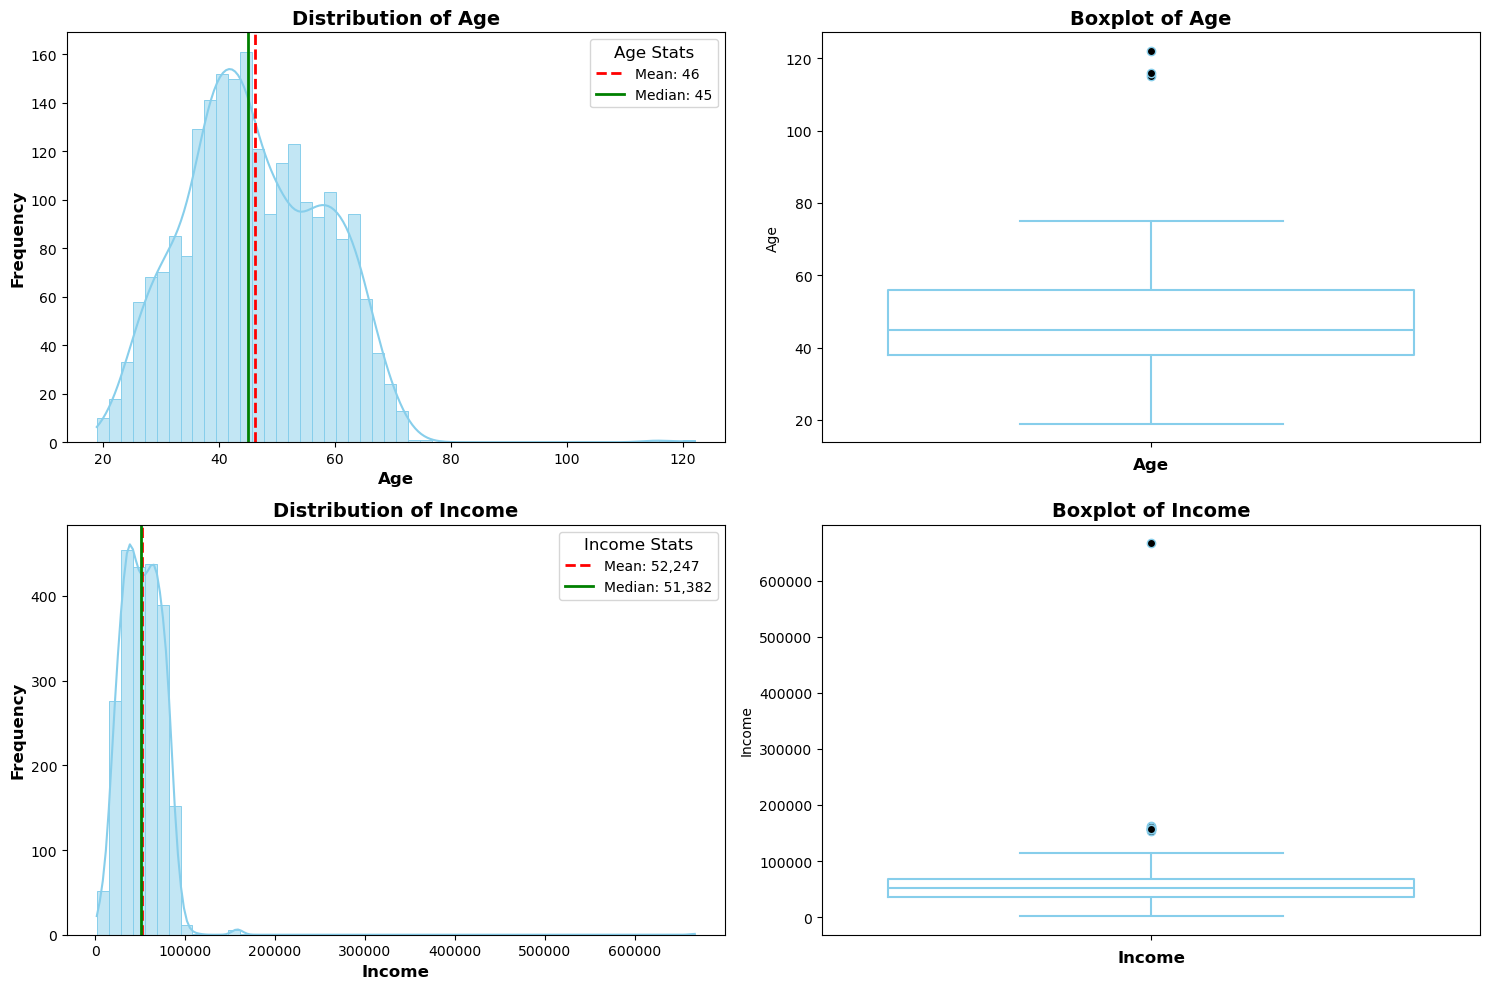

In [154]:
# Plot histogram with KDE
print()
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Income']
fig, axes = plt.subplots(len(cols), 2, figsize=(15, 5*len(cols)))

for i, col in enumerate(cols):
    y = customer_df[col]

    # Print stats
    print(f"""Statistics of {col}:
    Skewness : {y.skew():.4f}
    Kurtosis : {y.kurt():.4f}""") # kurtosis > 3 means heavy tails, more outliers than normal

    mean_val = y.mean()
    median_val = y.median()

    # Histogram
    sns.histplot(y, kde=True, bins=50, color='skyblue', ax=axes[i,0], edgecolor='skyblue')
    axes[i,0].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:,.0f}")
    axes[i,0].axvline(median_val, color="green", linestyle="-", linewidth=2, label=f"Median: {median_val:,.0f}")
    axes[i,0].set_title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    axes[i,0].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i,0].set_ylabel("Frequency", fontsize=12, fontweight='bold')
    axes[i,0].legend(title=f"{col} Stats", title_fontsize=12)

    # Boxplot
    sns.boxplot(y=y, color='skyblue', fill=False,
                flierprops={'marker':'o','markerfacecolor':'k'}, ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot of {col}", fontsize=14, fontweight='bold')
    axes[i,1].set_xlabel(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [155]:
# income outliers dataset
customer_df.query("Income > 161000")


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure
617,1503,1976,PhD,Partner,162397.0,1,1,2013-06-03,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0,39,1,2,3,6,2,2013,107,1,19
2233,9432,1977,Graduation,Partner,666666.0,1,0,2013-06-02,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0,38,1,1,2,6,2,2013,62,7,19


- There are several customers who earn more than 160,000 and some of them even more than 600,000. They are clearly outliers in the data.

In [156]:
# Removing outliers by setting a cap on income
customer_df = customer_df.query('Income < 161000')
customer_df.shape

(2214, 39)

**2.5. Data Visualization**

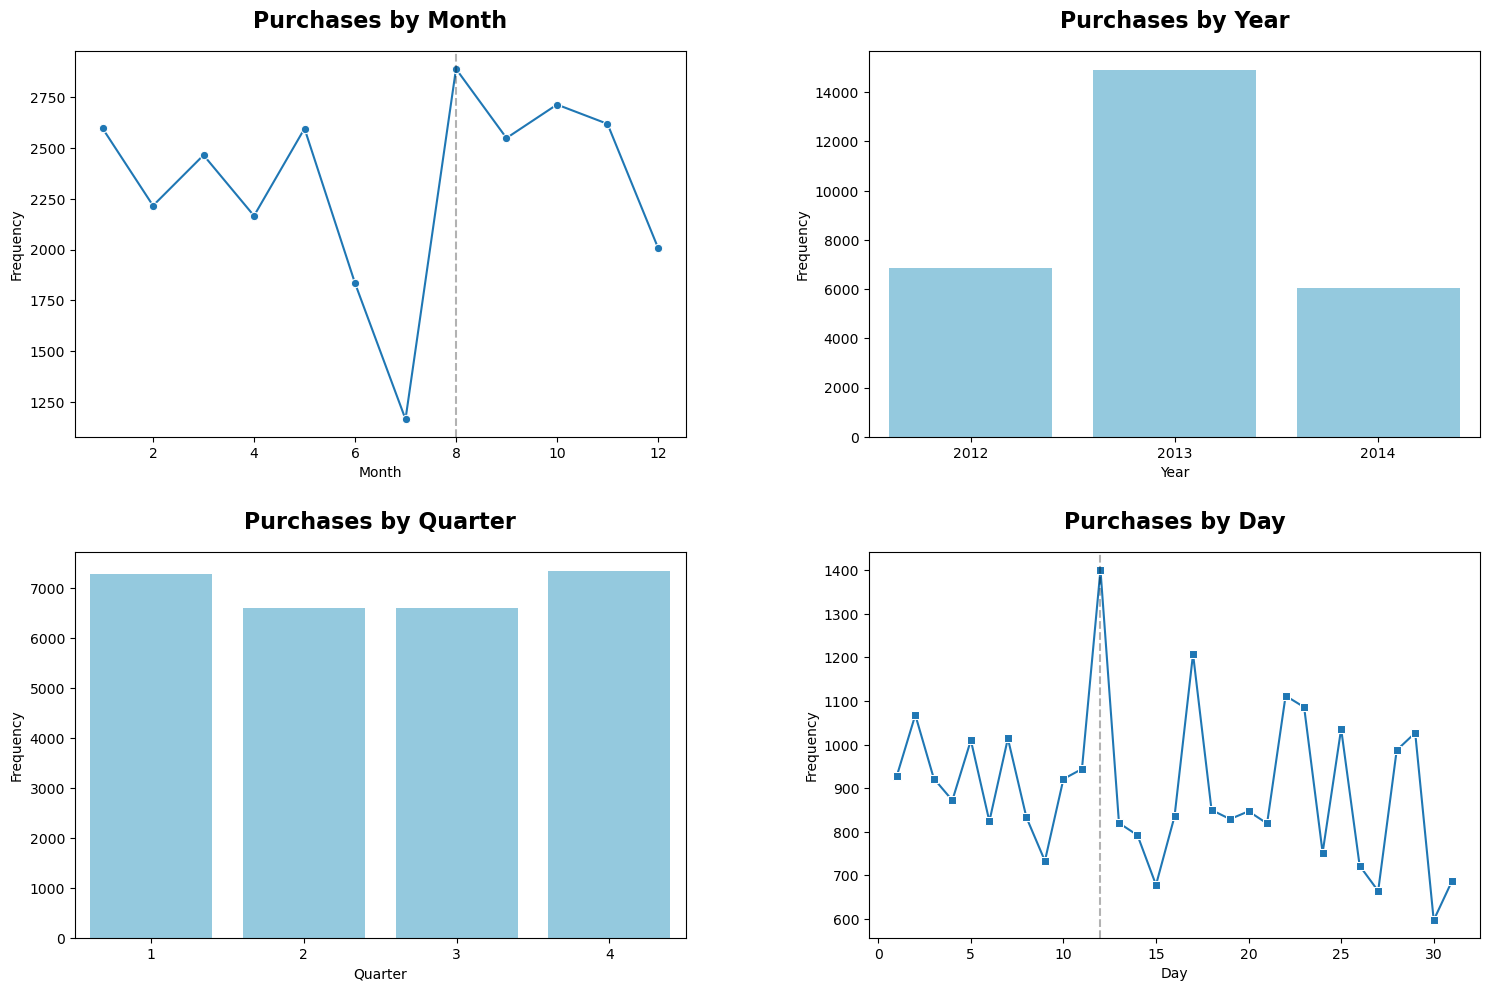

In [157]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Purchases by Month
sns.lineplot(
    data=customer_df.groupby('Month', as_index=False)['Frequency'].sum(),
    x='Month', y='Frequency', marker='o', ax=axes[0,0]
)
axes[0,0].set_title("Purchases by Month",fontsize=16, fontweight='bold', y=1.04)
axes[0,0].axvline(x=8, color="k", linestyle="--", alpha=0.3)

# Purchases by Year
sns.barplot(
    data=customer_df.groupby('Year', as_index=False)['Frequency'].sum(),
    x='Year', y='Frequency', ax=axes[0,1], color="skyblue"
)
axes[0,1].set_title("Purchases by Year", fontsize=16, fontweight='bold', y=1.04)

# Purchases by Quarter
sns.barplot(
    data=customer_df.groupby('Quarter', as_index=False)['Frequency'].sum(),
    x='Quarter', y='Frequency', ax=axes[1,0], color="skyblue"
)
axes[1,0].set_title("Purchases by Quarter", fontsize=16, fontweight='bold', y=1.04)

# Purchases by Day
sns.lineplot(
    data=customer_df.groupby('Day', as_index=False)['Frequency'].sum(),
    x='Day', y='Frequency', marker='s', ax=axes[1,1]
)
axes[1,1].set_title("Purchases by Day", fontsize=16, fontweight='bold', y=1.04)
axes[1,1].axvline(x=12, color="k", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


## **3. Customer Segmentation**

- Customer segmentation is the practice of dividing a customer base into distinct groups that share similar characteristics—such as demographics, behaviors, or preferences—so businesses can tailor their marketing strategies more effectively to each segment.

- Instead of viewing all customers as one group, segment them into similar clusters, study their traits, and run relevant campaigns—beyond just income or location. 

To analyze customer personalities, three different clustering techniques were applied to the RFM features. Each method groups customers with similar characteristics and reveals different segmentation patterns.

**K-means Clustering with Elbow Method:**

We use K-means clustering to group customers by __RFM method__, and apply the Elbow Method to identify the optimal number of clusters—pinpointing where additional clusters no longer significantly improve the fit.

**K-means Clustering with Silhouette Analysis:**

K-means clustering was again employed, but the Silhouette Score was used to assess cluster quality. By measuring how well customers fit within their assigned clusters, this method helps determine the optimal number of clusters for effective segmentation.

**Gaussian Mixture Model with BIC:**

This method applies Gaussian Mixture Models (GMM), allowing for more flexible cluster shapes than K-means. The optimal number of clusters is selected using the Bayesian Information Criterion (BIC), which balances model fit and complexity.


#### __3.1.K-means Clustering with Elbow Method__

In [158]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## select features based on which customers will be segmented
rfm = customer_df[['Recency', 'Frequency', 'Monetary']]
print(rfm.info())



<class 'pandas.core.frame.DataFrame'>
Index: 2214 entries, 0 to 2239
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    2214 non-null   int64
 1   Frequency  2214 non-null   int64
 2   Monetary   2214 non-null   int64
dtypes: int64(3)
memory usage: 69.2 KB
None


,no_cluster,wcss,explained_variance(%),pct_explained_variance
0,1,8.065504e+08,0.0000,NaN
1,2,1.834607e+08,0.7725,0.7725
2,3,8.230659e+07,0.8980,0.1255
3,4,4.768060e+07,0.9409,0.0429
4,5,3.212869e+07,0.9602,0.0193


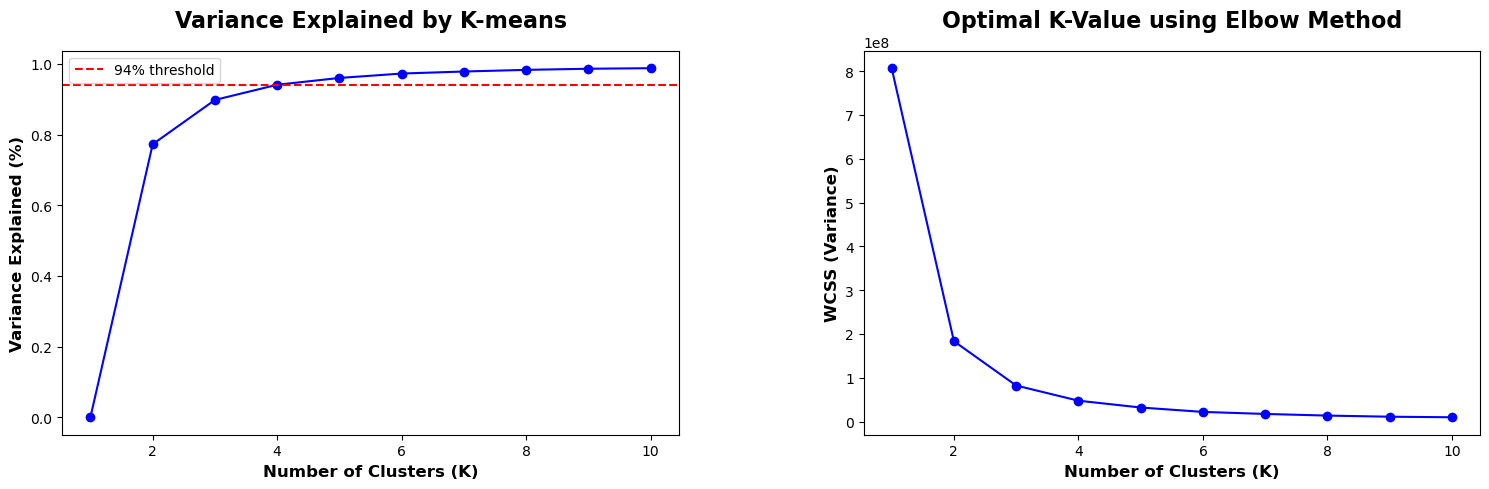

In [159]:
#  Total variance = sum of squared distances from mean
overall_mean = np.mean(np.array(rfm), axis=0)
total_variance = np.sum((np.array(rfm) - overall_mean)**2)

# KMeans Clustering with elbow method
wcss = []                           # Within-Cluster-Sum-of-Squares (WCSS)
explained_variance = []
n_cluster = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm)
    inertia = kmeans.inertia_
    wcss.append(inertia)
    bcss = total_variance - inertia      # between-cluster sum of squares
    explained_variance.append(bcss / total_variance)
    n_cluster.append(k)

# create dataframe
cluster_df = pd.DataFrame([], columns=['no_cluster', 'wcss', 'explained_variance(%)'])
cluster_df['no_cluster'] = n_cluster
cluster_df['wcss'] = wcss
cluster_df['explained_variance(%)'] = explained_variance
cluster_df['explained_variance(%)'] = cluster_df['explained_variance(%)'].map(lambda x: f'{x:.4f}').astype('float')
cluster_df = cluster_df.assign(pct_explained_variance=cluster_df['explained_variance(%)'].diff())
display(cluster_df.head())

# plot 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# plot no. of clusters with variance explained
ax[0].plot(range(1, 11), explained_variance, 'bo-')
ax[0].axhline(y=0.94, color='r', ls='--', label='94% threshold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax[0].set_title('Variance Explained by K-means', fontsize=16, fontweight='bold', y=1.04)
ax[0].legend()

# plot no. of clusters with elbow method
ax[1].plot(range(1, 11), wcss, 'bo-')
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('WCSS (Variance)', fontsize=12, fontweight='bold')
ax[1].set_title('Optimal K-Value using Elbow Method', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

In [161]:
# will choose the smallest k that explains at least 94% of the variance, which is k=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y = kmeans.fit_predict(rfm)

# Add cluster labels to the DataFrame
cluster_df = pd.DataFrame(customer_df)
cluster_df.loc[:,'Cluster'] = y

# Interpret Clusters
cluster_summary = cluster_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg('mean')
cluster_summary['n_customers'] = cluster_df.groupby('Cluster').size()
cluster_summary['percentage_customers'] = ((cluster_summary['n_customers']/cluster_summary['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_summary)



,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,49.034972,6.017958,100.494329,1058,47.8%
1,51.509225,20.059041,1767.811808,271,12.2%
2,47.128806,16.264637,575.100703,427,19.3%
3,49.336245,19.805677,1122.580786,458,20.7%


#### **3.2. K-means Clustering with Silhouette Analysis:**

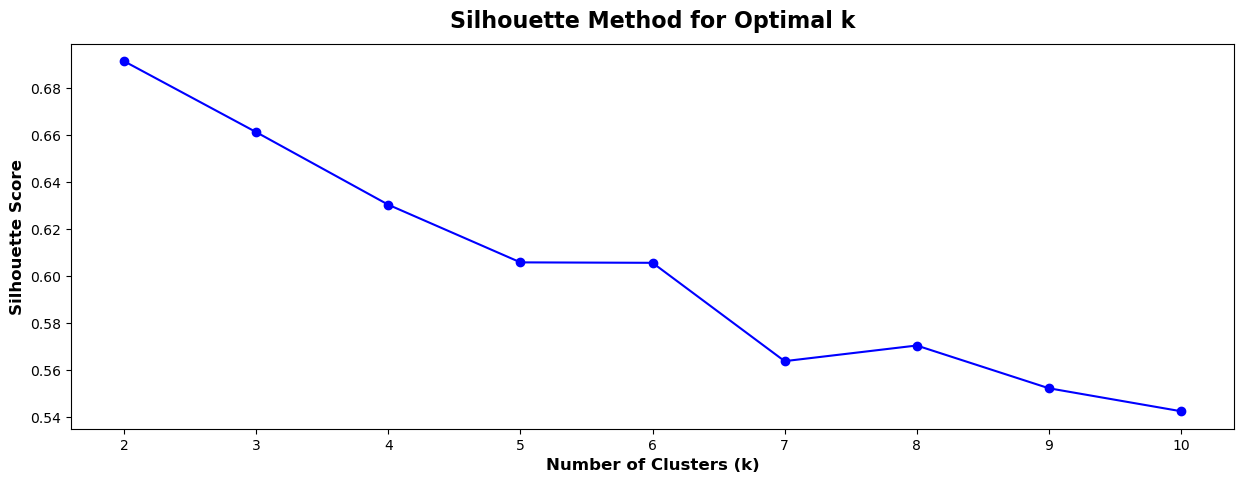

Optimal number of clusters: 2


,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,48.558927,8.436838,209.708539,1417,64.0%
1,49.874529,19.904642,1314.872020,797,36.0%


In [162]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters as silhouette score is not defined for 1 cluster

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm)
    score = silhouette_score(rfm, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(15, 5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Method for Optimal k', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Find the optimal number of clusters (highest silhouette score)
optimal_k = K[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

# Perform K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y = kmeans.fit_predict(rfm)

# Add cluster labels to the DataFrame
cluster_data = pd.DataFrame(customer_df)
cluster_data.loc[:,'Cluster'] = y

# Interpret clusters
cluster_analysis = cluster_data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg('mean')
cluster_analysis['n_customers'] = cluster_data.groupby('Cluster').size()
cluster_analysis['percentage_customers'] = ((cluster_analysis['n_customers']/cluster_analysis['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_analysis)


#### **3.3. Gaussian Mixture Model with BIC**

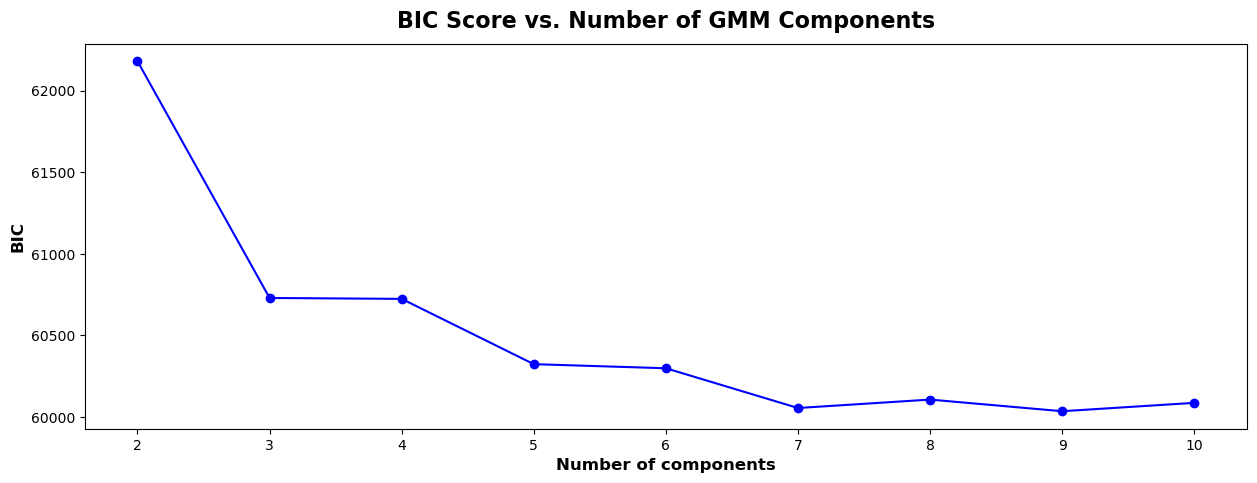

The optimal number of components based on BIC: 9



,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,48.402141,4.570336,45.469419,654,29.5%
1,52.688136,18.098305,1293.586441,295,13.3%
2,48.715100,20.860399,842.202279,351,15.9%
3,55.537313,22.522388,1194.358209,67,3.0%
4,49.514493,17.318841,1915.246377,138,6.2%
5,51.566396,8.165312,179.663957,369,16.7%
6,38.266667,20.516667,1572.933333,60,2.7%
7,43.633333,17.783333,688.083333,60,2.7%
8,44.386364,13.450000,417.586364,220,9.9%


In [163]:
from sklearn.mixture import GaussianMixture

# compute BIC and silhouette scores for different numbers of components
n_components_range = range(2, 11)
bic = []
silhouette_scores = []

for n_components in n_components_range:
    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(rfm)

    # Calculate BIC score
    bic.append(gmm.bic(rfm))

# Plot the BIC scores
print()
plt.figure(figsize=(15, 5))
plt.plot(n_components_range, bic, 'bo-')
plt.xlabel('Number of components', fontsize=12, fontweight='bold')
plt.ylabel('BIC', fontsize=12, fontweight='bold')
plt.title('BIC Score vs. Number of GMM Components', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Find the optimal number of components (lowest BIC)
optimal_components = n_components_range[np.argmin(bic)]
print(f"The optimal number of components based on BIC: {optimal_components}\n")

# Fit GMM with the optimal number of components
gmm = GaussianMixture(n_components=optimal_components, random_state=42)
y = gmm.fit_predict(rfm)

# Add cluster labels to the original dataframe
gmm_clustering_df = pd.DataFrame(customer_df)
gmm_clustering_df.loc[:, 'Cluster'] = y

# Interpret clusters
cluster_analysis = gmm_clustering_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg('mean')
cluster_analysis['n_customers'] = gmm_clustering_df.groupby('Cluster').size()
cluster_analysis['percentage_customers'] = ((cluster_analysis['n_customers']/cluster_analysis['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_analysis)


##### __Clustering Analysis of Customers in the customer personality Dataset__

- **K-means clustering + elbow method optimization**,  customers were divided into 4 distinct clusters.

- **K-means clustering + silhouette score optimization**, the dataset was grouped customers into 2 clusters.

- **Gaussian Mixture Model + Bayesian Information Criterion (BIC)**, the customers were separated into 9 clusters.

To maintain interpretability and provide a clear representation of customer personalities, the **K-means clustering solution optimized with the elbow method** was selected, yielding four meaningful customer segments.

In [164]:
# K-means cluster with elbow method
display(cluster_summary)

,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,49.034972,6.017958,100.494329,1058,47.8%
1,51.509225,20.059041,1767.811808,271,12.2%
2,47.128806,16.264637,575.100703,427,19.3%
3,49.336245,19.805677,1122.580786,458,20.7%


#### **Interpretation of RFM-based K-means clusters:**

##### __Cluster 0 — Low-value / occasional customers (Largest segment: 47.8%)__
- Recency: 49.03 (moderate–high)
- Frequency: 6.02 (very low)
- Monetary: 100.49 (very low)

__Interpretation__:
These are __infrequent and low-spending__ customers who haven't purchased recently. They contribute the least revenue but form the largest portion of the customer base.

__Business meaning__:

- Weak engagement and low loyalty
- High potential churn risk
- Likely "one-time" or inactive customers

__Strategy__:
Reactivation campaigns, discounts, and targeted promotions to bring them back.

---
##### __Cluster 1 — High-value loyal customers (Premium segment: 12.2%)__
- Recency: 51.51 (moderate)
- Frequency: 20.06 (highest)
- Monetary: 1767.81 (highest by far)

__Interpretation__:
They purchase **frequently and spend significantly** more than others, making them the most **profitable segment**.

__Business meaning__:

- Core revenue drivers
- Likely repeat buyers across channels

__Strategy__:
Retention focus: VIP programs, personalized offers, early access.

---
##### __Cluster 2 — Medium engagement, low spend customers (19.3%)__
- Recency: 47.13 (best / most recent among clusters)
- Frequency: 16.26 (moderate-high)
- Monetary: 575.10 (moderate-low)

__Interpretation__:
These customers are **active and relatively recent buyers**, but their spending is moderate. They engage fairly often but in **low-value purchases**.

**Business meaning:**

- Good engagement but low basket value
- Potential to upgrade into higher-value customers
- Responsive to marketing

__Strategy__:
Upselling and cross-selling to increase basket size.

---

##### __Cluster 3 — High-frequency, medium-value customers (20.7%)__
- Recency: 49.34 (moderate)
- Frequency: 19.81 (high)
- Monetary: 1122.58 (high)

__Interpretation__:
These are **frequent shoppers with solid spending** levels, but not as valuable as Cluster 1.

__Business meaning__:

- Strong repeat behavior
- Medium-to-high revenue contribution
- Close to premium segment

__Strategy__:
Retention + upselling to convert them into top-tier customers.

---

##### **Overall insight & Name Each Segment**
- __Cluster 0__ = __At-Risk Low-Value Customers__ (inactive / low-value mass customers) 
- __Cluster 2__ = __Potential Growth Customers__ (active but low-spending customers (growth opportunity)) 
- __Cluster 3__ = Loyal Regular Customers (loyal frequent buyers (strong mid-tier))
- __Cluster 1__ = __Champions / VIP Customers__ (VIP/high-value customers (key revenue drivers)) 

